# Reproduction notebook

**Tradeoffs Between Rate and Conditional Content with Encoder-Observed Context**
(IEEE Transactions on Information Theory submission, single author).

This notebook reproduces every closed form, table, and figure of the
manuscript from first principles, then runs the three verification
harnesses that accompany it. It is a demonstration; the proofs in the
paper stand on their own and do not depend on anything computed here.

What it covers, with the manuscript's numbering:

| Section below | Manuscript object |
|---|---|
| 1 | Theorem 15(a): the closed form $L(D)=\tfrac12\log_2 g^\star$, checked against direct minimization over test channels |
| 2 | Corollary 16: the three classical corners (Shannon, Gray, Steinberg) |
| 3 | Theorem 15(b) and Corollary 19: the rate-content frontier and the endpoint excesses; Figs. 2 and 3 regenerated |
| 4 | Corollary 21: non-determination by the reduced marginal, with the exact surds |
| 5 | Remark 22: attainment of the conditional-variance bound |
| 6 | Theorem 26 and Proposition 27: the binary tilt root and frontier; Fig. 4 regenerated |
| 7 | The verification harnesses: `verify_converses.py` (19 checks), `verifier_sym_checks.py`, `verifier_num_checks.py` |

Requirements: Python 3.10+, numpy, scipy, sympy, matplotlib. Run from the
paper directory (the one containing `tit-cr-context.tex`). Figures are
written to a scratch directory, not over the committed ones. The MATLAB
symbolic checks and the Lean 4 formalization are run separately; their
results are recorded in `VERIFICATION.md`.

Conventions (Section III of the paper): the described variable $Y$ and the
context $V$ are normalized to unit variance with correlation $\rho$; the
third party holds $S=V+U$ with $U\sim\mathcal N(0,\tau^2)$; $s=1+\tau^2$; the
distortion level is $0<D<1$; every jointly Gaussian test channel is
$\hat Y=aY+bV+N$ with $N\sim\mathcal N(0,\nu)$.

In [1]:
import os, sys, tempfile, math
import numpy as np, scipy, sympy as sp, matplotlib
from scipy.optimize import minimize, brentq
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

PAPER = os.getcwd()
assert os.path.exists(os.path.join(PAPER, "tit-cr-context.tex")), "run from the paper directory"
SCRATCH = tempfile.mkdtemp(prefix="tit_cr_context_")
print("paper dir :", PAPER)
print("scratch   :", SCRATCH)
print("numpy", np.__version__, "| scipy", scipy.__version__, "| sympy", sp.__version__, "| matplotlib", matplotlib.__version__)

paper dir : C:\source\geometric-observation\paper\tit-cr-context
scratch   : C:\Users\abptl\AppData\Local\Temp\tit_cr_context_8t_7b_cv
numpy 2.5.2 | scipy 1.18.1 | sympy 1.14.0 | matplotlib 3.10.8


## 1. The closed form (Theorem 15(a))

With $s=1+\tau^2$ the paper's quadratic is
$$P(g)=Dsg^2-(D+s-\rho^2)g+(1-\rho^2),$$
and $L(D)=\tfrac12\log_2 g^\star$ with $g^\star$ its larger root. For a
jointly Gaussian channel $\hat Y=aY+bV+N$ the three moments are
$Q_0=\operatorname{Var}(aY+bV)$, $Q_1=\operatorname{Var}(aY+bV\mid S)$, and
$h=\operatorname{Var}((1-a)Y-bV)$, so that the distortion is $h+\nu$, the
rate is $\tfrac12\log_2\frac{Q_0+\nu}{\nu}$, and the conditional content is
$\tfrac12\log_2\frac{Q_1+\nu}{\nu}$. The cell below evaluates the closed form
and compares it with a direct multi-start minimization of the conditional
content over $(a,b)$ with the distortion constraint active,
$\nu=D-h(a,b)$.

In [2]:
def P(g, rho2, tau2, D):
    s = 1 + tau2
    return D*s*g*g - (D + s - rho2)*g + (1 - rho2)

def gstar(rho2, tau2, D):
    s = 1 + tau2
    B = D + s - rho2
    return (B + math.sqrt(B*B - 4*D*s*(1 - rho2))) / (2*D*s)

def L_closed(rho2, tau2, D):
    return 0.5*math.log2(gstar(rho2, tau2, D))

def moments(a, b, rho2, tau2):
    rho, s = math.sqrt(rho2), 1 + tau2
    Q0 = a*a + b*b + 2*a*b*rho
    mu = (a*rho + b)/s
    Q1 = Q0 - s*mu*mu
    h = (1-a)**2 - 2*(1-a)*b*rho + b*b
    return Q0, Q1, h

def content(ab, rho2, tau2, D):
    a, b = ab
    Q0, Q1, h = moments(a, b, rho2, tau2)
    nu = D - h
    if nu <= 1e-12:
        return 50.0 + 1e3*(1e-12 - nu)
    return 0.5*math.log2((Q1 + nu)/nu)

def L_direct(rho2, tau2, D, starts=60, seed=0):
    rng = np.random.default_rng(seed)
    best = np.inf
    for _ in range(starts):
        x0 = rng.uniform(-1, 1, 2)
        r = minimize(content, x0, args=(rho2, tau2, D), method="Nelder-Mead",
                     options=dict(xatol=1e-11, fatol=1e-13, maxiter=4000))
        best = min(best, r.fun)
    return best

instances = [(0.5, 0.25, 0.3), (0.75, 0.5, 0.3), (0.2, 0.5, 0.1), (0.8, 0.05, 0.6), (0.3, 2.0, 0.45), (0.6, 1.0, 0.2)]
rows = ["| $(\\rho^2,\\tau^2,D)$ | $g^\\star$ | $P(g^\\star)$ | $L$ closed form | $L$ direct | difference (bits) |", "|---|---|---|---|---|---|"]
worst = 0.0
for r2, t2, D in instances:
    g = gstar(r2, t2, D); Lc = L_closed(r2, t2, D); Ld = L_direct(r2, t2, D)
    worst = max(worst, abs(Lc - Ld))
    rows.append(f"| ({r2}, {t2}, {D}) | {g:.6f} | {P(g, r2, t2, D):.1e} | {Lc:.6f} | {Ld:.6f} | {abs(Lc-Ld):.1e} |")
display(Markdown("\n".join(rows)))
print("largest |closed form - direct| over the six instances:", f"{worst:.2e}", "bits")
assert worst < 1e-6

| $(\rho^2,\tau^2,D)$ | $g^\star$ | $P(g^\star)$ | $L$ closed form | $L$ direct | difference (bits) |
|---|---|---|---|---|---|
| (0.5, 0.25, 0.3) | 2.191623 | 0.0e+00 | 0.566000 | 0.566000 | 4.4e-16 |
| (0.75, 0.5, 0.3) | 2.064194 | 2.2e-16 | 0.522789 | 0.522789 | 3.3e-16 |
| (0.2, 0.5, 0.1) | 8.721842 | 1.1e-15 | 1.562316 | 1.562316 | 0.0e+00 |
| (0.8, 0.05, 0.6) | 1.045587 | 0.0e+00 | 0.032157 | 0.032157 | 1.5e-16 |
| (0.3, 2.0, 0.45) | 2.084595 | -1.1e-15 | 0.529884 | 0.529884 | 3.3e-16 |
| (0.6, 1.0, 0.2) | 3.732051 | -3.3e-16 | 0.949984 | 0.949984 | 3.3e-16 |

largest |closed form - direct| over the six instances: 4.44e-16 bits


## 2. The three classical corners (Corollary 16)

At $\rho=0$ the closed form is Shannon's $\tfrac12\log_2(1/D)$; as
$\tau^2\to0$ it is Gray's conditional function
$\tfrac12\log_2^{+}\frac{1-\rho^2}{D}$; as $\rho^2\to1$ it meets Steinberg's
scalar formula at the induced correlation $\rho_{YS}^2=1/s$, which is
$\tfrac12\log_2\frac{\tau^2+D}{sD}$.

In [3]:
def steinberg_reduced(rhoYS2, D):
    return 0.5*math.log2((1 - rhoYS2 + rhoYS2*D)/D)

D, t2, r2 = 0.3, 0.5, 0.6
print("rho = 0        :", f"{L_closed(0.0, t2, D):.8f}", "vs Shannon", f"{0.5*math.log2(1/D):.8f}")
print("tau^2 -> 0     :", f"{L_closed(r2, 1e-9, D):.8f}", "vs Gray   ", f"{0.5*max(0.0, math.log2((1-r2)/D)):.8f}")
s = 1 + t2
print("rho^2 -> 1     :", f"{L_closed(1-1e-9, t2, D):.8f}", "vs Steinberg at rho_YS^2 = 1/s", f"{steinberg_reduced(1/s, D):.8f}")
print("Gray anchor in the far branch D > 1 - rho^2:", f"{L_closed(0.8, 1e-9, 0.5):.2e}", "(should be ~0)")

rho = 0        : 0.86848280 vs Shannon 0.86848280
tau^2 -> 0     : 0.20751875 vs Gray    0.20751875
rho^2 -> 1     : 0.41503750 vs Steinberg at rho_YS^2 = 1/s 0.41503750
Gray anchor in the far branch D > 1 - rho^2: 1.20e-09 (should be ~0)


## 3. The rate-content frontier (Theorem 15(b), Corollary 19)

The frontier is traced by minimizing $\alpha R+(1-\alpha)L$ over channels at
active distortion. The two endpoints are the rate minimizer ($\alpha=1$, the
classical reverse channel) and the content minimizer ($\alpha=0$, the closed
form). Corollary 19 says the endpoints differ, so each pays an excess in the
other coordinate, exactly when $0<\rho^2<1$; at the instance
$(\rho^2,\tau^2,D)=(0.75,0.5,0.3)$ the paper quotes excesses of $0.0400$
bits of rate and $0.0349$ bits of content.

In [4]:
def coords(ab, rho2, tau2, D):
    a, b = ab
    Q0, Q1, h = moments(a, b, rho2, tau2)
    nu = D - h
    if nu <= 1e-12:
        return None
    return 0.5*math.log2((Q0+nu)/nu), 0.5*math.log2((Q1+nu)/nu)

def weighted(ab, al, rho2, tau2, D):
    c = coords(ab, rho2, tau2, D)
    if c is None:
        a, b = ab; return 50.0 + 1e3*(moments(a, b, rho2, tau2)[2] - D + 1e-12)
    return al*c[0] + (1-al)*c[1]

def frontier_point(al, rho2, tau2, D, starts=40, seed=0):
    rng = np.random.default_rng(seed); best = None
    for _ in range(starts):
        r = minimize(weighted, rng.uniform(-1, 1, 2), args=(al, rho2, tau2, D), method="Nelder-Mead",
                     options=dict(xatol=1e-11, fatol=1e-13, maxiter=4000))
        if best is None or r.fun < best.fun: best = r
    return coords(best.x, rho2, tau2, D)

r2, t2, D = 0.75, 0.5, 0.3
pts = {al: frontier_point(al, r2, t2, D) for al in (0.0, 0.25, 0.5, 0.75, 1.0)}
for al, (R, L) in pts.items():
    print(f"alpha = {al:.2f}:  R = {R:.6f}  L = {L:.6f}")
Rmin, Lmin = 0.5*math.log2(1/D), L_closed(r2, t2, D)
print("R_min (reverse channel) =", f"{Rmin:.6f}", " L_min (closed form) =", f"{Lmin:.6f}")
print("excess rate at the content minimizer   :", f"{pts[0.0][0]-Rmin:.4f}", "bits  (paper: 0.0400)")
print("excess content at the rate minimizer   :", f"{pts[1.0][1]-Lmin:.4f}", "bits  (paper: 0.0349)")
assert abs(pts[0.0][1]-Lmin) < 1e-6 and abs(pts[1.0][0]-Rmin) < 1e-6

alpha = 0.00:  R = 0.908529  L = 0.522789
alpha = 0.25:  R = 0.889606  L = 0.525453
alpha = 0.50:  R = 0.877217  L = 0.532821
alpha = 0.75:  R = 0.870504  L = 0.543899
alpha = 1.00:  R = 0.868483  L = 0.557739
R_min (reverse channel) = 0.868483  L_min (closed form) = 0.522789
excess rate at the content minimizer   : 0.0400 bits  (paper: 0.0400)
excess content at the rate minimizer   : 0.0349 bits  (paper: 0.0349)


R_min          = 0.868483 bits (closed form 0.5*log2(1/D))
L_min = L(D)   = 0.522789 bits (closed form 0.5*log2(g*))
R_L*(D)        = 0.908529 bits  (traced endpoint, alpha=0)
L_R*(D)        = 0.557739 bits  (traced endpoint, alpha=1)
closed-form L_R*(D) = 0.557739
excess rate    R_L*-R_min = 0.0400 bits
excess content L_R*-L_min = 0.0349 bits
endpoint residuals: dR(alpha=1)=2.22e-16  dL(alpha=0)=5.55e-16  dL_R* vs closed form=7.95e-10


wrote frontier.pdf and frontier.png


rho^2=0.2: R_min=0.8685 R_L*=0.8892 L_min=0.7813 L_R*=0.7978 | rate gap dR=0.0207  content gap dL=0.0166


rho^2=0.5: R_min=0.8685 R_L*=0.9122 L_min=0.6411 L_R*=0.6768 | rate gap dR=0.0438  content gap dL=0.0357


rho^2=0.8: R_min=0.8685 R_L*=0.9037 L_min=0.5000 L_R*=0.5314 | rate gap dR=0.0352  content gap dL=0.0314


wrote frontier_multi.pdf and frontier_multi.png


**Fig. 2** (regenerated): the frontier at $(\rho^2,\tau^2,D)=(0.75,0.5,0.3)$

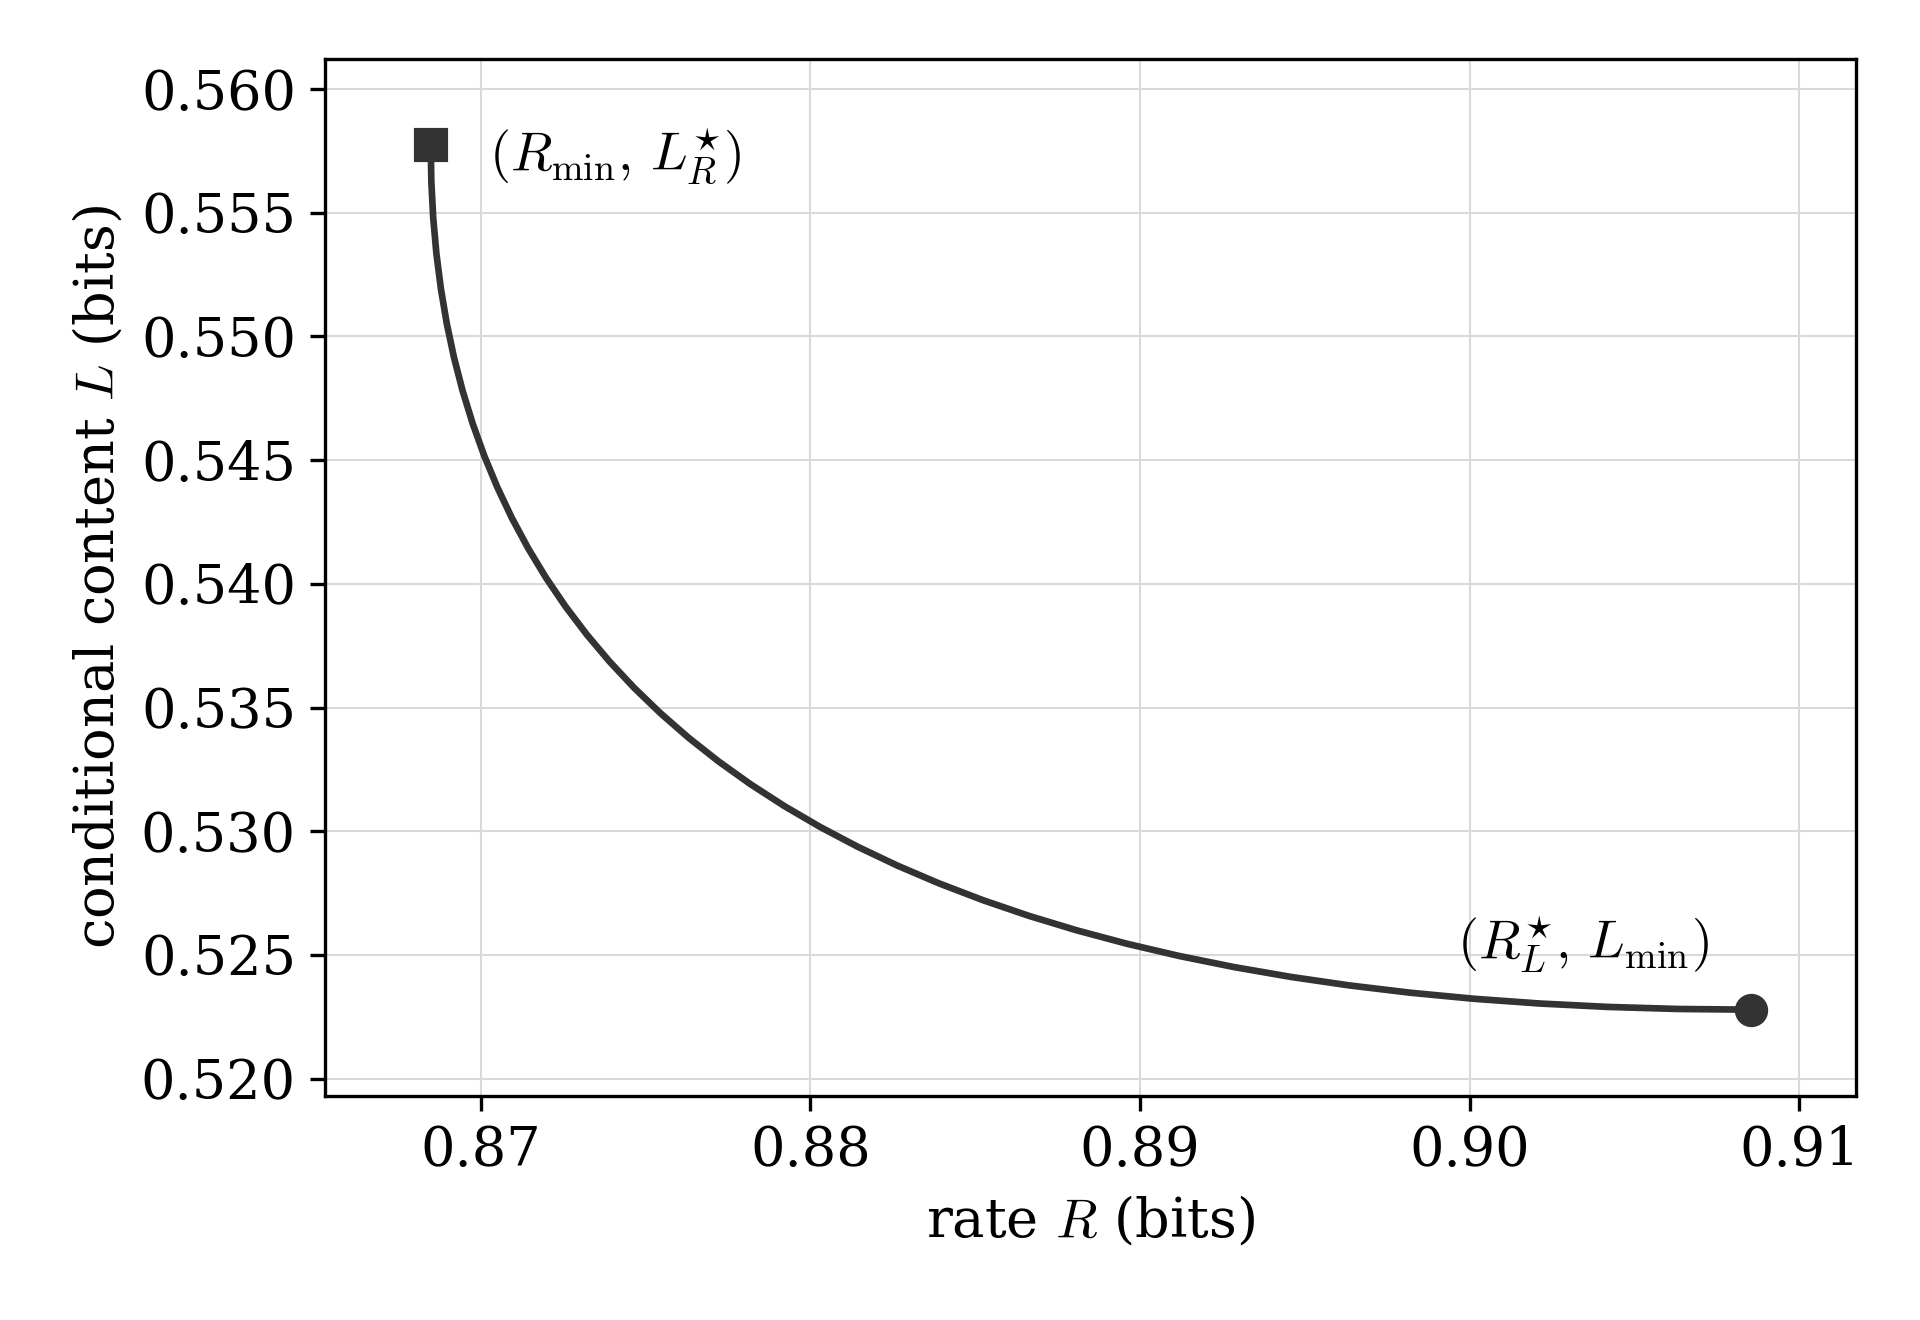

**Fig. 3** (regenerated): the frontier at $\rho^2\in\{0.2,0.5,0.8\}$, $\tau^2=0.5$, $D=0.3$

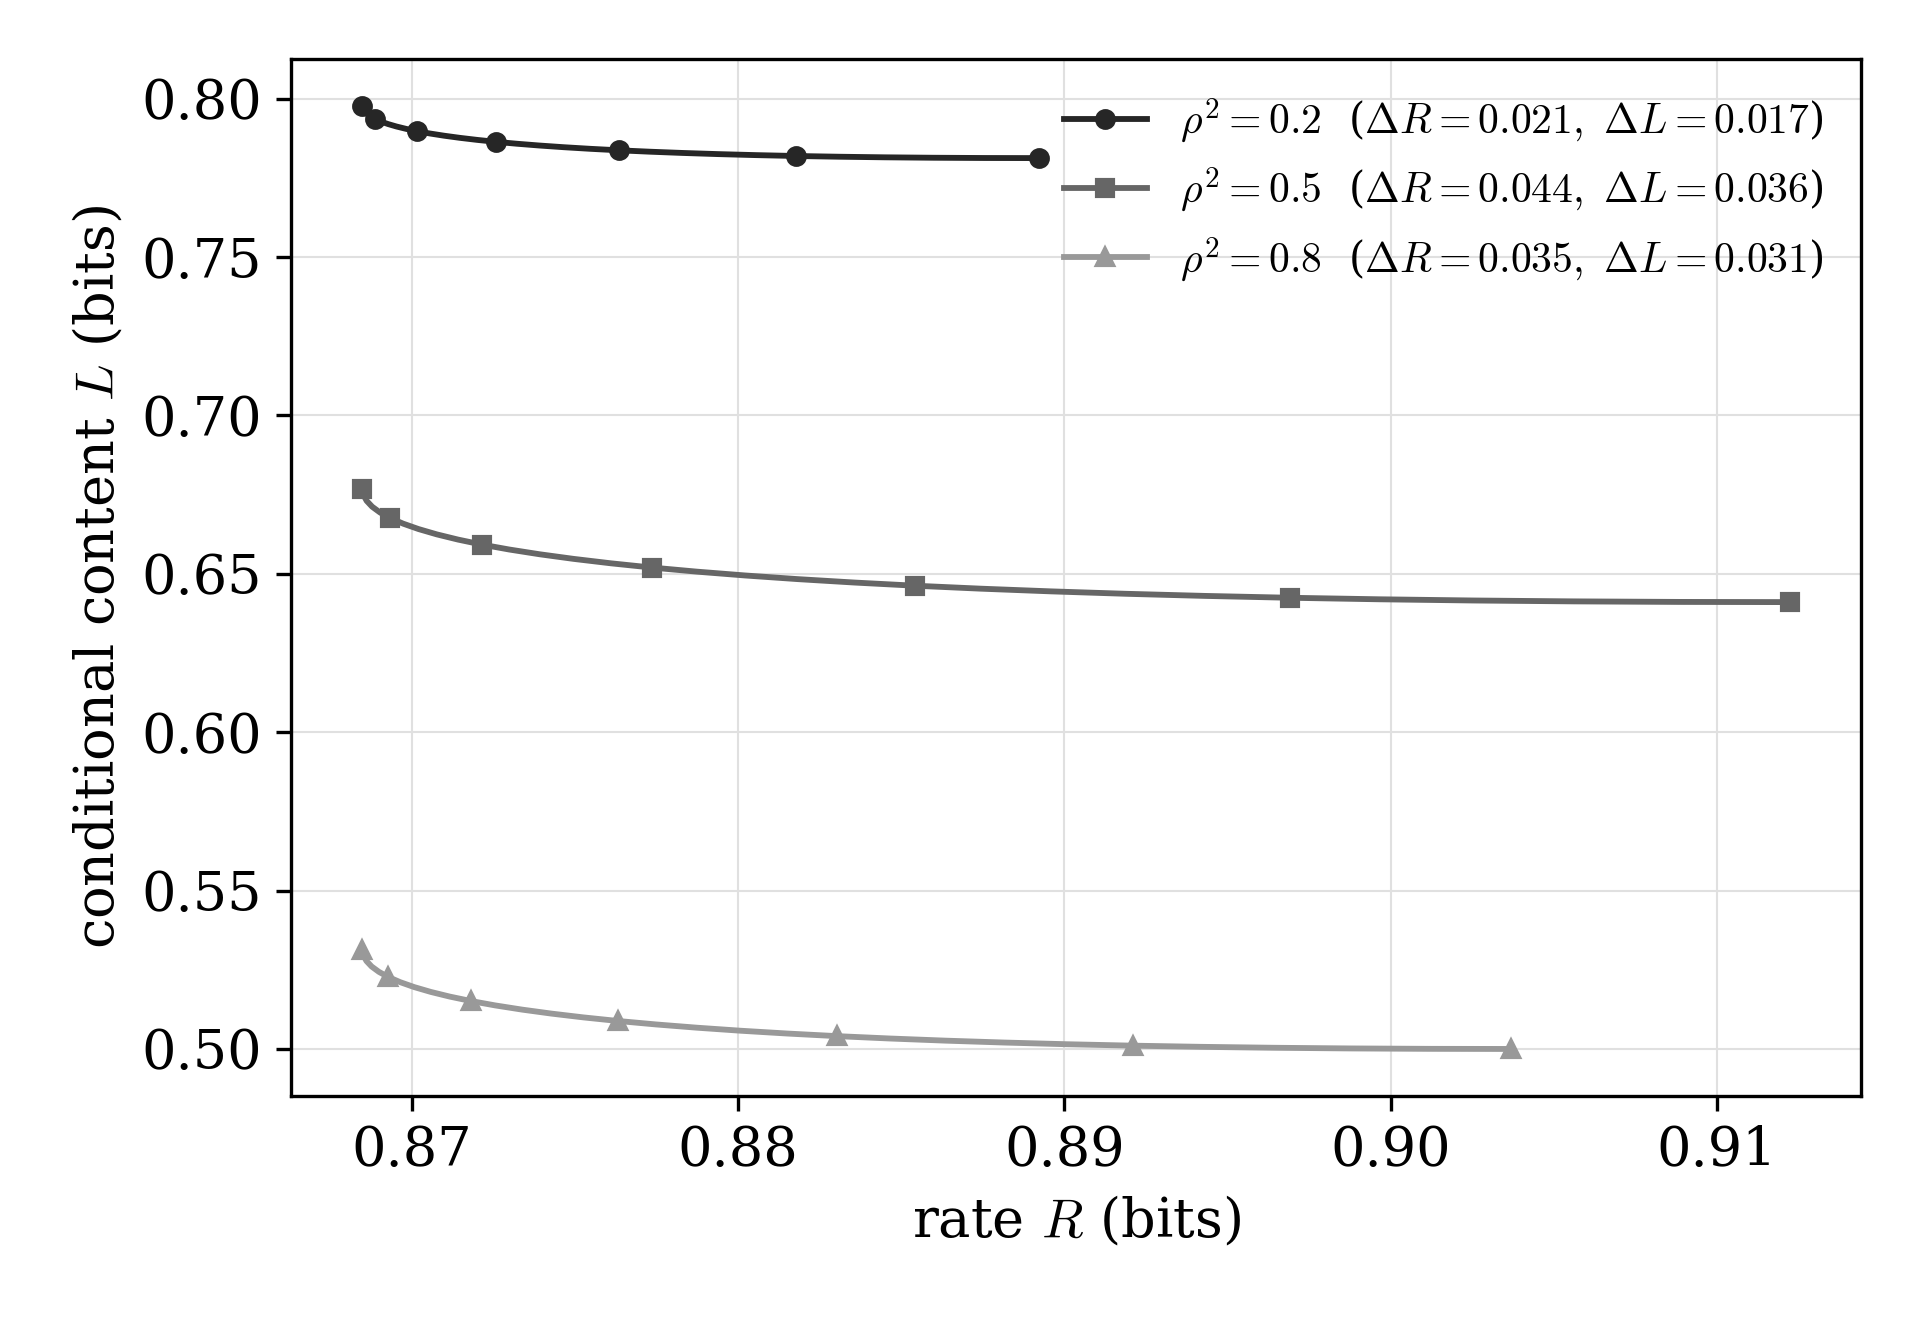

In [5]:
os.chdir(SCRATCH)
%run -i {PAPER}/plot_frontier.py
%run -i {PAPER}/plot_frontier_multi.py
os.chdir(PAPER)
display(Markdown("**Fig. 2** (regenerated): the frontier at $(\\rho^2,\\tau^2,D)=(0.75,0.5,0.3)$"))
display(Image(os.path.join(SCRATCH, "frontier.png"), width=520))
display(Markdown("**Fig. 3** (regenerated): the frontier at $\\rho^2\\in\\{0.2,0.5,0.8\\}$, $\\tau^2=0.5$, $D=0.3$"))
display(Image(os.path.join(SCRATCH, "frontier_multi.png"), width=520))

## 4. Non-determination by the reduced marginal (Corollary 21)

The instances $(\rho^2,\tau^2)=(\tfrac12,0)$ and $(\tfrac34,\tfrac12)$ have
the same reduced correlation $\rho_{YS}^2=\rho^2/s=\tfrac12$ but different
conditional content, and both lie below Steinberg's scalar formula evaluated
on the reduced pair. The paper's exact forms for the second instance are
$g^\star=(17+\sqrt{229})/6$ at $D=0.1$ and $(21+\sqrt{261})/18$ at $D=0.3$.

In [6]:
rows = ["| instance | $\\rho_{YS}^2$ | $L$ at $D=0.1$ | $L$ at $D=0.3$ |", "|---|---|---|---|"]
for r2, t2 in ((0.5, 0.0), (0.75, 0.5)):
    rows.append(f"| $(\\rho^2,\\tau^2)=({r2},{t2})$ | {r2/(1+t2):.4f} | {L_closed(r2, t2, 0.1):.4f} | {L_closed(r2, t2, 0.3):.4f} |")
rows.append(f"| Steinberg on the reduced pair | 0.5000 | {steinberg_reduced(0.5, 0.1):.4f} | {steinberg_reduced(0.5, 0.3):.4f} |")
display(Markdown("\n".join(rows)))
print("exact surds:", abs(gstar(0.75, 0.5, 0.1) - (17+math.sqrt(229))/6), abs(gstar(0.75, 0.5, 0.3) - (21+math.sqrt(261))/18))
print("gaps between the instances: ", f"{L_closed(0.75,0.5,0.1)-L_closed(0.5,0.0,0.1):.4f}", "bits at D = 0.1,",
      f"{L_closed(0.75,0.5,0.3)-L_closed(0.5,0.0,0.3):.4f}", "bits at D = 0.3")

| instance | $\rho_{YS}^2$ | $L$ at $D=0.1$ | $L$ at $D=0.3$ |
|---|---|---|---|
| $(\rho^2,\tau^2)=(0.5,0.0)$ | 0.5000 | 1.1610 | 0.3685 |
| $(\rho^2,\tau^2)=(0.75,0.5)$ | 0.5000 | 1.2105 | 0.5228 |
| Steinberg on the reduced pair | 0.5000 | 1.2297 | 0.5577 |

exact surds: 8.881784197001252e-16 4.440892098500626e-16
gaps between the instances:  0.0495 bits at D = 0.1, 0.1543 bits at D = 0.3


## 5. Attainment of the conditional-variance bound (Remark 22)

Every admissible channel obeys $L\ge\tfrac12\log_2\frac{\operatorname{Var}(Y\mid S)}{D}=\tfrac12\log_2 g_f$ with
$g_f=(s-\rho^2)/(Ds)$. Substituting into the quadratic gives
$P(g_f)=-\rho^2\tau^2/s$, so on the active regime $D\le1-\rho^2$ the bound is
attained exactly when $\rho\tau=0$.

In [7]:
rng = np.random.default_rng(1)
worst = 0.0
for _ in range(200):
    r2, t2, D = rng.uniform(0.05, 0.95), rng.uniform(0.0, 3.0), rng.uniform(0.05, 0.95)
    s = 1 + t2; gf = (s - r2)/(D*s)
    worst = max(worst, abs(P(gf, r2, t2, D) + r2*t2/s))
print("max |P(g_f) + rho^2 tau^2 / s| over 200 random instances:", f"{worst:.1e}")
for r2, t2, D in ((0.5, 0.0, 0.3), (0.0, 0.5, 0.3), (0.5, 0.5, 0.3)):
    s = 1 + t2; gf = (s - r2)/(D*s)
    print(f"(rho^2, tau^2, D) = ({r2}, {t2}, {D}):  L = {L_closed(r2,t2,D):.6f}   bound = {0.5*math.log2(gf):.6f}   attained: {abs(L_closed(r2,t2,D)-0.5*math.log2(gf))<1e-12}")

max |P(g_f) + rho^2 tau^2 / s| over 200 random instances: 1.0e-14
(rho^2, tau^2, D) = (0.5, 0.0, 0.3):  L = 0.368483   bound = 0.368483   attained: True
(rho^2, tau^2, D) = (0.0, 0.5, 0.3):  L = 0.868483   bound = 0.868483   attained: True
(rho^2, tau^2, D) = (0.5, 0.5, 0.3):  L = 0.641078   bound = 0.576002   attained: False


## 5b. Comparison with Lu and Xu's vector Gaussian Heegard-Berger function

Lu and Xu (WCSP 2021, Theorem 4) give the common-reconstruction
rate-distortion function for two decoders under diagonal positive definite
error-covariance constraints $\mathbf D_m\preceq\mathbf K_X$. Specialized to
one decoder with side information $S$ and constraint $\mathrm{diag}(D,D_V)$ on
$(Y,V)$ it is $R(D,D_V)=\tfrac12\log_2\frac{(1-\rho^2)(\tau^2+D_V)}{sDD_V}$,
since $\mathbf K_1=\Sigma_{T\mid S}^{-1}-\Sigma_T^{-1}=\mathrm{diag}(0,\tau^{-2})$
is already diagonal. The hypothesis forces $(1-D)(1-D_V)\ge\rho^2$, so
$D_V\le D_V^{\max}=1-\rho^2/(1-D)$. The cell checks four things: the
specialization returns Steinberg's scalar formula for a scalar source; the
auxiliary matrix is diagonal; $R(D,D_V^{\max})>L(D)$ on random admissible
instances; and the formal extension to $D_V=\operatorname{Var}V=1$ equals
Gray's clean-context function, a strict lower bound on $L(D)$ when
$\rho\tau\ne0$.

In [8]:
def luxu_single(rho2, tau2, D, DV):
    s = 1 + tau2
    return 0.5*math.log2((1-rho2)*(tau2+DV)/(s*D*DV))

# scalar sanity: source variance sX2, side information X+U, U variance sU2
sX2, sU2, Dd = 2.0, 0.5, 0.3
KXY = sX2*sU2/(sX2+sU2); K1 = 1/KXY - 1/sX2
print("scalar specialization vs Steinberg:", f"{0.5*math.log2(KXY*(1/Dd+K1)):.10f}", f"{0.5*math.log2(sX2*(sU2+Dd)/((sX2+sU2)*Dd)):.10f}")

r2, t2 = 0.5, 0.25; s = 1 + t2
KX = np.array([[1, math.sqrt(r2)], [math.sqrt(r2), 1]]); c = np.array([[math.sqrt(r2)], [1.0]])
KXS = KX - c @ c.T / s
print("K_1 = Sigma_{T|S}^{-1} - Sigma_T^{-1} =", np.round(np.linalg.inv(KXS) - np.linalg.inv(KX), 10).tolist(), " (1/tau^2 =", 1/t2, ")")

rng = np.random.default_rng(0); gaps = []
while len(gaps) < 10000:
    r2, t2, D = rng.uniform(0.02, 0.98), rng.uniform(0.01, 4.0), rng.uniform(0.01, 0.99)
    if D >= 1 - r2: continue
    DVmax = 1 - r2/(1-D)
    gaps.append(luxu_single(r2, t2, D, DVmax) - L_closed(r2, t2, D))
gaps = np.array(gaps)
print("R(D, D_V^max) - L(D) over 10000 admissible instances: min", f"{gaps.min():.2e}", " median", f"{np.median(gaps):.4f}", " negatives:", int((gaps < 0).sum()))
assert (gaps > 0).all()
for r2, t2, D in ((0.5, 0.25, 0.3), (0.75, 0.5, 0.1)):
    print(f"({r2},{t2},{D}): L = {L_closed(r2,t2,D):.4f}   R(D_V^max) = {luxu_single(r2,t2,D,1-r2/(1-D)):.4f}   R(D_V=1) = {luxu_single(r2,t2,D,1.0):.4f}   Gray = {0.5*math.log2((1-r2)/D):.4f}")

scalar specialization vs Steinberg: 0.5465547022 0.5465547022
K_1 = Sigma_{T|S}^{-1} - Sigma_T^{-1} = [[0.0, -0.0], [-0.0, 4.0]]  (1/tau^2 = 4.0 )


R(D, D_V^max) - L(D) over 10000 admissible instances: min 4.73e-06  median 0.1023  negatives: 0
(0.5,0.25,0.3): L = 0.5660   R(D_V^max) = 0.6610   R(D_V=1) = 0.3685   Gray = 0.3685
(0.75,0.5,0.1): L = 1.2105   R(D_V^max) = 1.3685   R(D_V=1) = 0.6610   Gray = 0.6610


## 6. The binary case (Theorem 26, Proposition 27)

For the doubly symmetric binary source with $\Pr[Y\ne V]=p$ and a binary
symmetric context channel of crossover $q$, the conditional content along the
constraint segment is $L(d_0)=h_2(u)-(1-p)h_2(d_0)-p\,h_2(d_1)$ with
$d_1=(D-(1-p)d_0)/p$, $a=2(1-p)d_0+p-D$, $u=a(1-2q)+q$, and the minimizer is
the root of the tilt equation
$\psi(d_0)=2(1-2q)\ell(u)-\ell(d_0)+\ell(d_1)=0$, $\ell(x)=\ln\frac{1-x}{x}$.
The rate along the segment is $R(d_0)=1-(1-p)h_2(d_0)-p\,h_2(d_1)$, minimized
at $d_0=d_1=D$. At $(p,q,D)=(0.1,0.1,0.05)$ the paper reports
$d_0^\star=0.0282$, $L_{\min}=0.4341$, $R_{\min}=0.7136$, and excesses of
$0.0391$ bits of rate and $0.0248$ bits of content.

tilt root d0* = 0.0282   L_min = 0.4341   R at d0* = 0.7527
rate minimizer d0 = D:  R_min = 0.7136 = 1 - h2(D) = 0.7136   L there = 0.4589
excess rate at the content minimizer: 0.0391   excess content at the rate minimizer: 0.0248
segment: d0 in (0.0000, 0.2000)
tilt root d0* = 0.1173  (d1* = 0.2480, u* = 0.3432)
L(d0*) = 0.3346 bits
psi(d0*) = 2.22e-16
sign changes of psi on grid: 1

frontier instance (p,q,D) = (0.1, 0.1, 0.05)
segment: d0 in (0.0000, 0.0556)
tilt root d0* = 0.0282  (L-minimizer)
L_min = L(d0*)          = 0.4341 bits
R_min = 1 - h2(D)       = 0.7136 bits  (at d0 = D = 0.05)
R(d0*) - R_min          = 0.0391 bits  (rate excess of L-optimum)
L(D) - L_min            = 0.0248 bits  (content excess of R-optimum)


wrote binary.pdf and binary.png


**Fig. 4** (regenerated): tilt root, objective, and the binary rate-content frontier

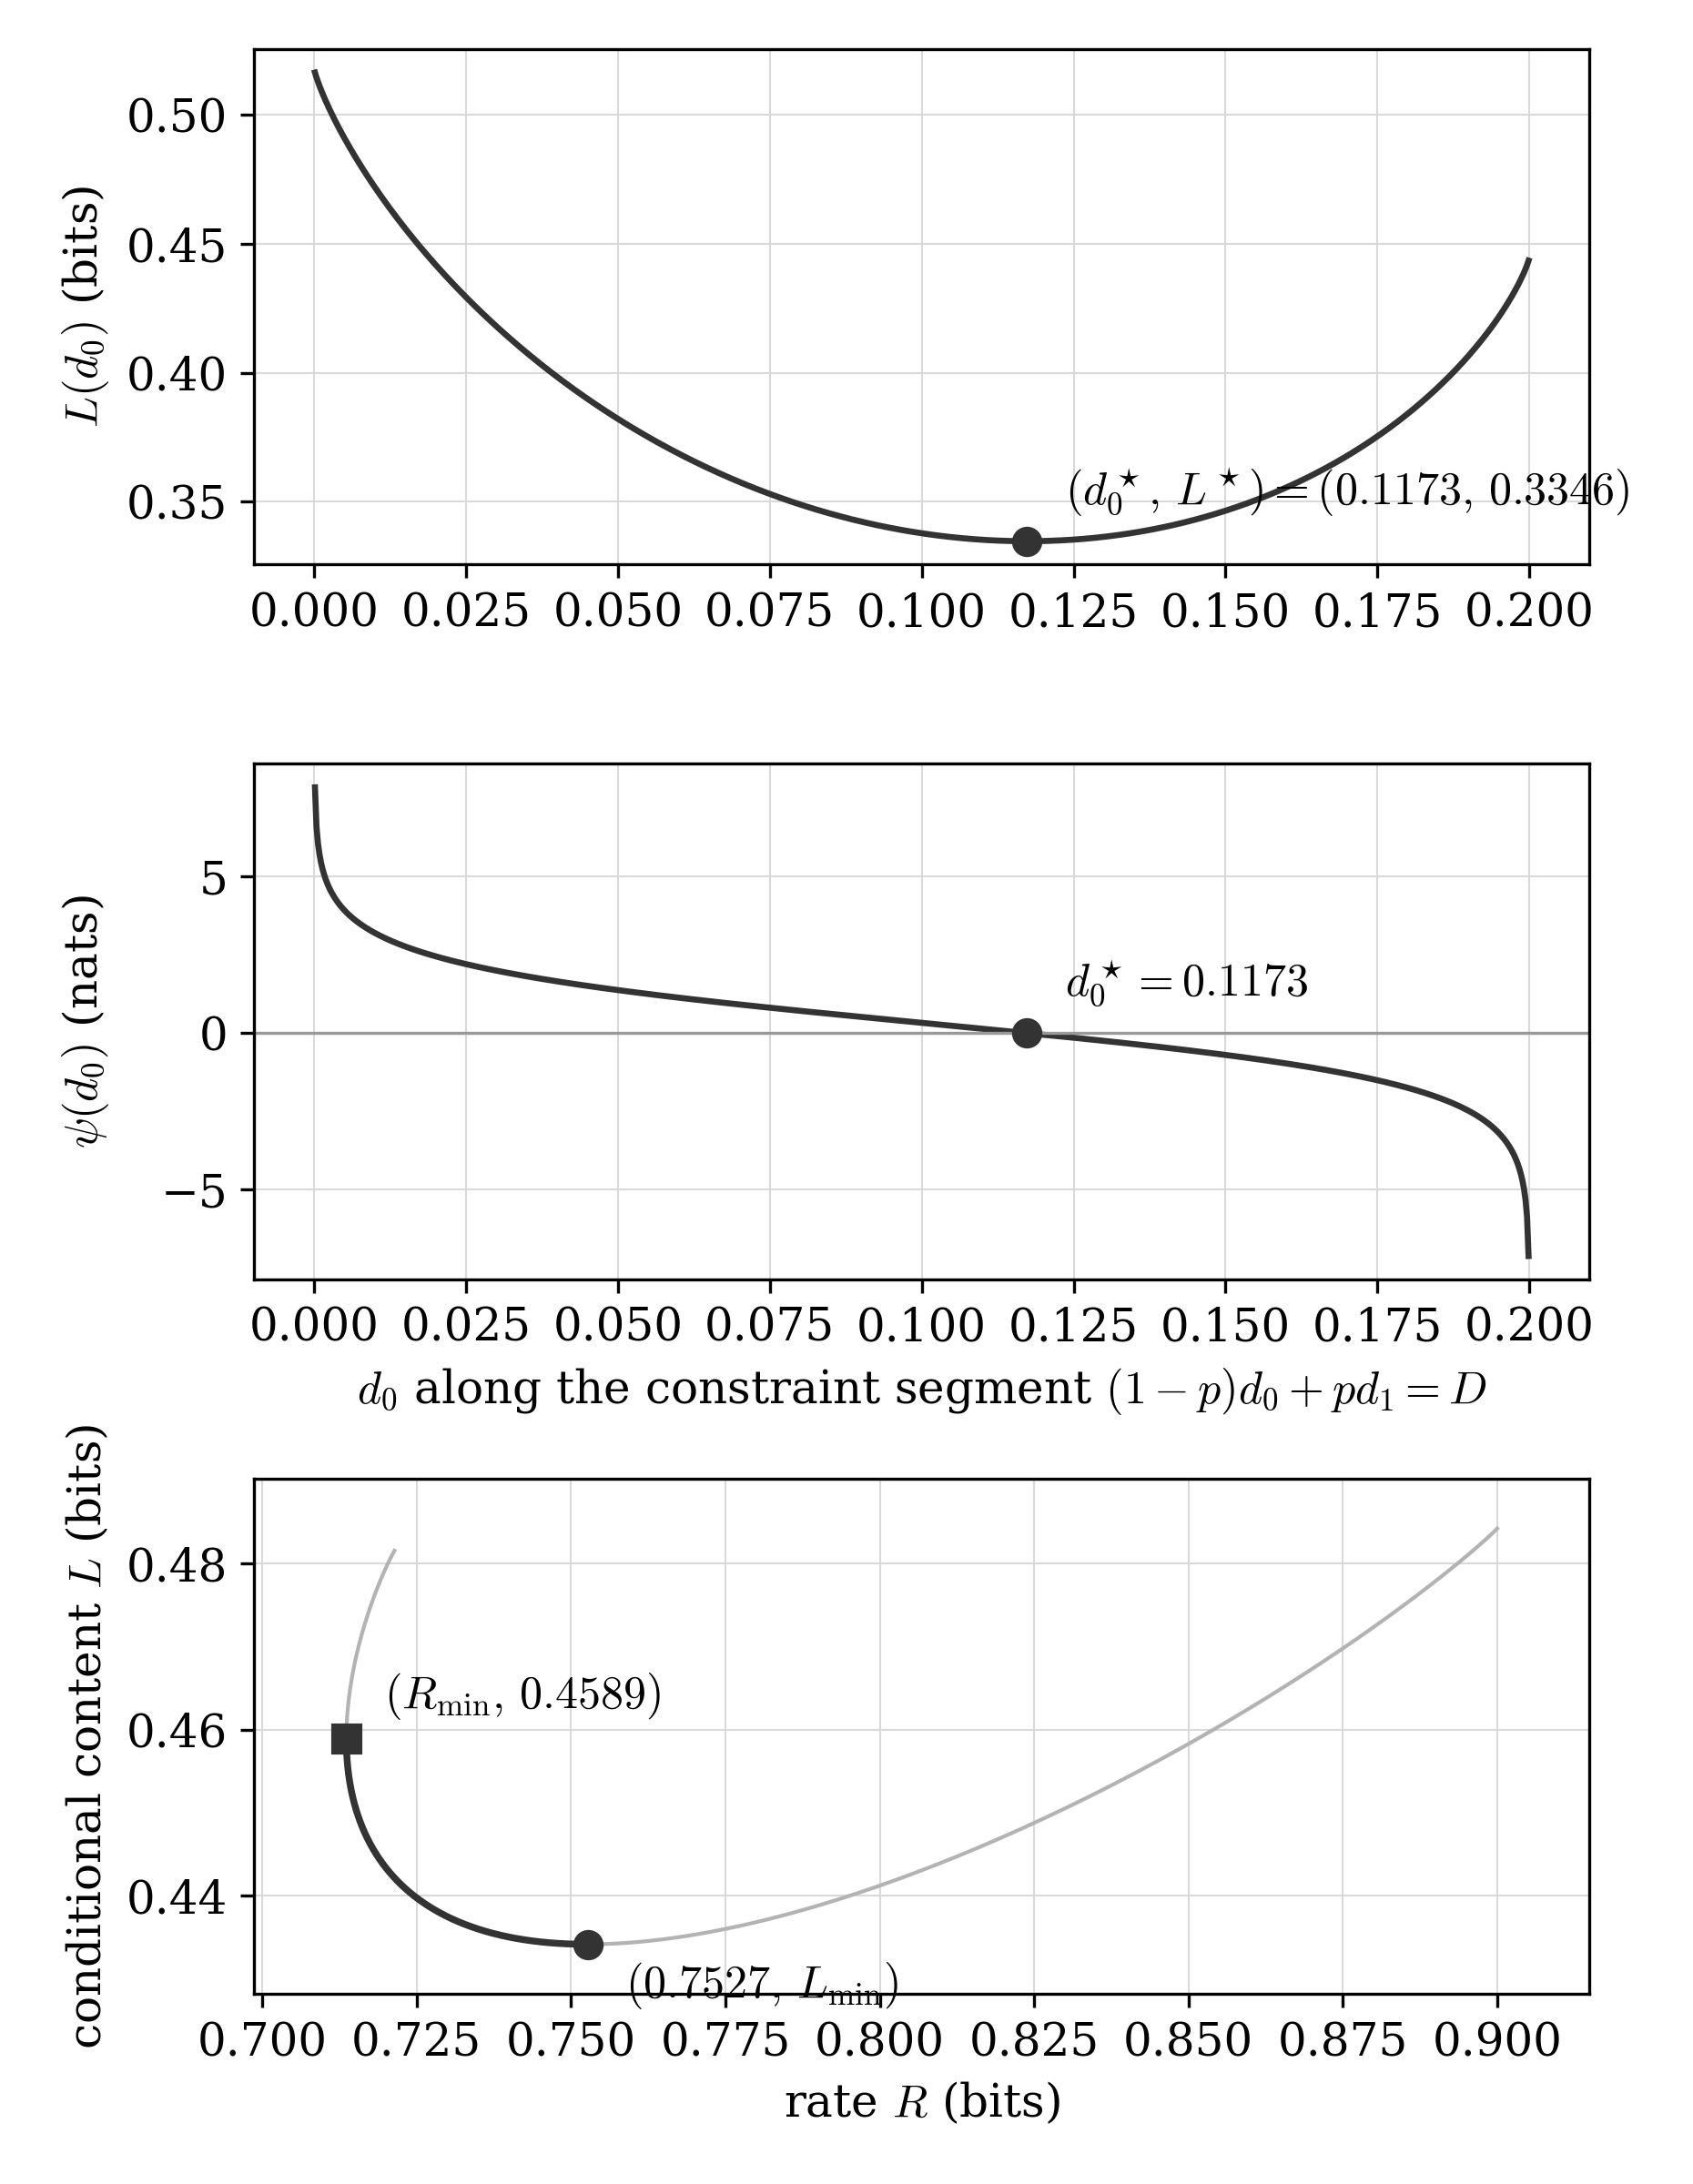

In [9]:
def h2(x):
    x = np.clip(x, 1e-15, 1-1e-15); return -(x*np.log2(x) + (1-x)*np.log2(1-x))
def ell(x): return math.log((1-x)/x)
p, q, D = 0.1, 0.1, 0.05
d1 = lambda d0: (D - (1-p)*d0)/p
u = lambda d0: (2*(1-p)*d0 + p - D)*(1-2*q) + q
Lb = lambda d0: h2(u(d0)) - (1-p)*h2(d0) - p*h2(d1(d0))
Rb = lambda d0: 1 - (1-p)*h2(d0) - p*h2(d1(d0))
psi = lambda d0: 2*(1-2*q)*ell(u(d0)) - ell(d0) + ell(d1(d0))
hi = D/(1-p)
d0s = brentq(psi, 1e-9, hi - 1e-9)
print(f"tilt root d0* = {d0s:.4f}   L_min = {Lb(d0s):.4f}   R at d0* = {Rb(d0s):.4f}")
print(f"rate minimizer d0 = D:  R_min = {Rb(D):.4f} = 1 - h2(D) = {1-h2(D):.4f}   L there = {Lb(D):.4f}")
print(f"excess rate at the content minimizer: {Rb(d0s)-Rb(D):.4f}   excess content at the rate minimizer: {Lb(D)-Lb(d0s):.4f}")
os.chdir(SCRATCH)
%run -i {PAPER}/plot_binary.py
os.chdir(PAPER)
display(Markdown("**Fig. 4** (regenerated): tilt root, objective, and the binary rate-content frontier"))
display(Image(os.path.join(SCRATCH, "binary.png"), width=640))

## 7. The verification harnesses

`verify_converses.py` is the author's harness (nineteen checks, symbolic and
numeric). `verifier_sym_checks.py` and `verifier_num_checks.py` were
commissioned independently, without access to the derivations or to the
first script. Each prints one line per check and a final verdict, and exits
nonzero on any failure. The inventory of what each check covers is in
`VERIFICATION.md`; some checks cover material that now lives only in the
archived full-length versions of the paper.

In [10]:
%run {PAPER}/verify_converses.py

PASS  S1 conditional determinant identity det Sig_{T|S}/det Sig_e = (Q1+n)/n
PASS  S2 rate determinant identity det Sig_T/det Sig_e0 = (Q0+n)/n
PASS  S3 four gradient identities d(Q0-h), d(Q1-h) w.r.t. (a,b)
PASS  S4 stationarity system linear in (a,b) at fixed g; solution matches eq:ab


PASS  S5 (g-1)(D-h) - Q1 = P(g) (g-1)/(g k) at the stationary point
PASS  S6 P(g_f) = -rho^2 tau^2/s at g_f = (s-rho^2)/(Ds)


PASS  S7 weighted FOC solves to a = 1-a g0-(1-a)g1, b = (1-a) g1 mu_c


PASS  N1 closed form L(D) vs direct (a,b,n) minimization, 6 instances  [max dev 3.89e-16 bits]


PASS  N2 frontier at alpha in {0,0.5,1} vs direct weighted min, 2 instances  [max dev 2.07e-09 bits]
PASS  N3 cor:notmarginal arithmetic to 4 decimals + strict margin ordering  [L1(0.1)=1.1610, L2(0.1)=1.2105, St(0.1)=1.2297, L1(0.3)=0.3685, L2(0.3)=0.5228, St(0.3)=0.5577]
PASS  N4 cor:misalign endpoint excesses 0.0400 / 0.0349 at (0.75,0.5,0.3)  [R(0)-Rmin=0.0400, L(1)-Lmin=0.0349]


...

PASS  N6 rem:cleanboundary tau=0 displays and strict gap, 3 instances  [(0.5,0.2): Lmin=0.6610, LR=0.7925; (0.75,0.1): Lmin=0.6610, LR=0.8502; (0.3,0.8): Lmin=0.0000, LR=0.1163]
PASS  N7 binary tilt residual: exactly one sign change on segment (grid)  [729 (p,q,D) cells]


PASS  N8 lem:cleanctx: conditional program = B_det iff Delta <= Sigma_{Y|V}  [inside: 2.611196 vs 2.611196; outside: 2.130204 > 2.087543]


PASS  N9 I(Yhat;S_Delta) increases to I(Yhat;S) under refinement  [I_Delta: 0.27176, 0.28996, 0.42074, 0.46984, 0.48190, 0.48479 -> 0.48572]
PASS  N10 binary frontier: closed forms vs joint-pmf evaluation + caption  [max dev 2.78e-16; d0*=0.0282, Lmin=0.4341, Rmin=0.7136, dR=0.0391, dL=0.0248]


PASS  N11 endpoint-excess magnitudes: box maxima, divergence, saturation  [box max dR=0.1138@(np.float64(0.5), np.float64(0.25), np.float64(0.5)), dL=0.0770@(np.float64(0.615), np.float64(0.25), np.float64(0.385)); dR(0.5,1e-3,0.5)=1.537; dL->half*log2(1.5)=0.2923 vs 0.2925]


PASS  N12 anchor convergence rates: implicit-diff coefficients + numeric  [sym exact: True; worst |ratio-1| = 8.0e-04]

ALL 19 CHECKS PASS


In [11]:
%run {PAPER}/verifier_sym_checks.py

PASS Sigma_{T|S} entries (line ~660)
PASS det Sigma_{T|S} = tau^2(1-rho^2)/s
PASS Q1 = A Sigma_{T|S} A^T = Q0-(a rho+b)^2/s (line ~669)
PASS distortion identity h = 1-2(a+b rho)+Q0 (eq:distortion)


PASS det M = s(Q1+n) (line ~675)


PASS det Sigma_e = n det Sigma_{T|S}/(Q1+n) (eq:scalar-detid)


PASS det Sigma_{T|S}/det Sigma_e = (Q1+n)/n
PASS det K = s * det Sigma_{T|S} * n
PASS det K = det M * det Sigma_e


PASS det Sigma_e0 = det Sigma_T * n/(Q0+n) (thm:region rate identity)
PASS chat^T SigT^{-1} chat = Q0
PASS grad id d_a(Q0-h)=2
PASS grad id d_b(Q0-h)=2rho
PASS grad id d_a(Q1-h)=2(1-rho*mu)
PASS grad id d_b(Q1-h)=2(rho-mu)
PASS grad id d_a h = 2(a+b rho-1)
PASS grad id d_b h = 2(a rho+b-rho)
PASS mu_c consistency: (aE rho + bE)/s == rho(g-1)/k
PASS FOC-1: a+b rho = 1-(1-rho mu)/g
PASS FOC-2: a rho+b = rho-(rho-mu)/g


...

PASS region FOC in a matches eq:foc-a


PASS region FOC in b matches eq:foc-b
PASS focB - rho*focA = (1-rho^2)(b-(1-alpha) g1 mu)
PASS focA with b=(1-a)g1 mu gives a = 1-alpha g0-(1-alpha) g1
PASS alpha=1 endpoint: gamma0=D
PASS cor:misalign L(1) ratio = [(1-D)(1-rho^2/s)+D]/D
PASS det(I-cc^T/v) = n/v


PASS det(Lam - (Lam c)(Lam c)^T/sigma) = det(Lam) n/sigma
PASS sigma = Q1+n  (v - c^T(I-Lam)c)


PASS vector FOC matches displayed system (pre-collection)


PASS collection: FOC <=> bracket*c = rhs (eq:vecfoc)

FAILURES: none


In [12]:
%run {PAPER}/verifier_num_checks.py

PASS thm:function value = brute-force min over (a,b), 60 random instances max val err 5.69e-16
PASS thm:function optimizer = (a*,b*) of eq:channel max moment err 1.58e-08
PASS achieving channel meets distortion with equality (h+n=D) max err 9.99e-16
PASS I(T;Yhat|S) from joint covariance entropies = (1/2)log2 g* max err 1.33e-15
PASS anchor rho=0: g*=1/D 
PASS anchor tau->0 rho2=0.3: g*->max(1,(1-rho2)/D) 3.50000000
PASS anchor tau->0 rho2=0.85: g*->max(1,(1-rho2)/D) 1.00000000
PASS anchor tau->0 rho2=0.95: g*->max(1,(1-rho2)/D) 1.00000000
PASS anchor tau->0 at double-root boundary rho2=0.8,D=0.2 (O(tau) rate) 
PASS anchor rho2->1: g*->(D+tau2)/(D s) 2.33333333
PASS notmarginal: g* surd (D=0.1) matches quadratic root 5.355458
PASS notmarginal: g* surd (D=0.3) matches quadratic root 2.064194
   values: L(inst1,D=.1)=1.160964  L(inst2,D=.1)=1.210505  Steinberg=1.229716
   values: L(inst1,D=.3)=0.368483  L(inst2,D=.3)=0.522789  Steinberg=0.557739
PASS notmarginal quoted decimals (1.1610, 

PASS two-water-level system holds at brute minimizers, alpha grid worst residual 3.69e-09
PASS frontier monotone: R increasing, L decreasing as alpha->0 [(0.0, np.float64(0.9085), np.float64(0.5228)), (0.25, np.float64(0.8896), np.float64(0.5255)), (0.5, np.float64(0.8772), np.float64(0.5328)), (0.75, np.float64(0.8705), np.float64(0.5439)), (1.0, np.float64(0.8685), np.float64(0.5577))]
PASS alpha=0 endpoint matches thm:function (gamma1=1/g*) dL=-5.55e-16 dR=1.18e-09
PASS alpha=1 endpoint: (R,L)=(Rmin, L(1)) dR=-1.11e-16 dL=-2.26e-10
PASS prop:uniq spot: all multistarts converge to one point (alpha=0.5) spread 6.10e-09
PASS lem:gauss determinant identity, 200 random (p=3,r=2,m=2) instances max rel err 2.52e-13


PASS lem:mxconvex: (1-t)F0+tF1-F(zt) PSD over 300 random trials min eig -3.59e-16
PASS prop:uniq: midpoint convexity of B_alpha on domain D, 300 trials min gap 2.14e-03


PASS thm:vector r=2 trial 0: alpha=0 scalar-root value = brute min brute 0.38632759, roots [np.float64(0.38632759)]


PASS thm:vector r=2 trial 1: alpha=0 scalar-root value = brute min brute 0.28855019, roots [np.float64(0.28855019)]


PASS thm:vector r=2 trial 2: alpha=0 scalar-root value = brute min brute 0.03428439, roots [np.float64(0.03428439)]


PASS thm:vector r=2 trial 3: alpha=0 scalar-root value = brute min brute 0.18457041, roots [np.float64(0.18457041)]


PASS thm:vector r=2 trial 4: alpha=0 scalar-root value = brute min brute 0.83462530, roots [np.float64(0.8346253)]
PASS thm:vector eq:vecfoc holds at brute minimizer (alpha=0.4, r=2) max residual 1.95e-09
PASS whitening: W SigT W^T = I 
PASS whitening: W SigTcS W^T = Lambda diag 
PASS whitening: |y0| = 1 


PASS thm:vector r=1 alpha=0 value = thm:function value 0.522789330 vs 0.522789330
PASS r=1 minimizer maps via c=W^{-T}(a,b) [-0.65946407 -0.25777472] vs [-0.65946407 -0.25777472]


PASS r=1 alpha=0.5 weighted values agree (vector vs scalar coords) 0.705018980 vs 0.705018980
PASS prop:marg channel D=0.1: distortion=D and I(X;Yhat|S)=0.5log2(1/(2D)) dist 0.100000, MI 1.160964
PASS prop:marg channel D=0.3: distortion=D and I(X;Yhat|S)=0.5log2(1/(2D)) dist 0.300000, MI 0.368483

FAILURES: none


## 8. Environment

The MATLAB symbolic checks (`matlab_checks.m`, 11 checks) and the Lean 4
module (`lean/ObservationTheory/CRContext.lean` in the repository, zero
`sorry`) are run outside this notebook; their most recent results are
recorded in `VERIFICATION.md`.

In [13]:
import platform
print(platform.python_version(), platform.platform())
print("numpy", np.__version__, "| scipy", scipy.__version__, "| sympy", sp.__version__, "| matplotlib", matplotlib.__version__)

3.12.2 Windows-10-10.0.19045-SP0
numpy 2.5.2 | scipy 1.18.1 | sympy 1.14.0 | matplotlib 3.10.8
